# ***UCITAVANJE CSV FAJLA***
Ovaj nacin nam omogucava uploadovanje fajla direktno u coolab, moramo imati dataset na racunaru negde pa se izabere.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving healthcare-dataset-stroke-data.csv to healthcare-dataset-stroke-data.csv


In [ ]:
import pandas as pd
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
print(df.head())
print(df.shape)

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  
(5110, 12)


# ***Data analysis***


---



Stavke u ovom datasetu su:

- id
- gender
- age
- hypertension
- heart_disease
- ever_married
- work_type
- residence_type
- avg_glucose_level
- bmi
- smoking_status
- stroke





### ***Pretraga jedinstvenih vrednosti u kategorickim kolonama***

In [ ]:
#lista kolona za koje zelim da mi izbaci jedinstvene vrednosti koje ima

columns_to_check = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

for column in columns_to_check:
    unique_values = df[column].unique()
    value_counts = df[column].value_counts()
    print(f"Unique values in '{column}': {unique_values}")
    print(f"Counts of each unique value in '{column}':\n{value_counts}\n")


#df sadrzi dataset u kom radim, [column] pristupa specificnoj koloni u tom sto sam definisala
#npr column = 'gender'
#.unique() PANDAS METOD koji vraca niz jedinstvenih vrednosti u odabranoj koloni, ide kroz celu kolonu i daje takve vrednosti preskacuci duplikate


Unique values in 'gender': ['Male' 'Female' 'Other']
Counts of each unique value in 'gender':
gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

Unique values in 'ever_married': ['Yes' 'No']
Counts of each unique value in 'ever_married':
ever_married
Yes    3353
No     1757
Name: count, dtype: int64

Unique values in 'work_type': ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Counts of each unique value in 'work_type':
work_type
Private          2925
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

Unique values in 'Residence_type': ['Urban' 'Rural']
Counts of each unique value in 'Residence_type':
Residence_type
Urban    2596
Rural    2514
Name: count, dtype: int64

Unique values in 'smoking_status': ['formerly smoked' 'never smoked' 'smokes' 'Unknown']
Counts of each unique value in 'smoking_status':
smoking_status
never smoked       1892
Unknown            1544
formerly sm

Posto postoji samo jedan other u kategoriji gender moze da se izbaci, nije relevantno za dalju analizu.



Objasnjenje koda


---


- df sadrzi dataset u kom radim
- [column] pristupa specificnoj koloni u tom sto sam definisala *npr column = 'gender'*

- .unique() **PANDAS METOD** koji vraca niz jedinstvenih vrednosti u odabranoj koloni, ide kroz celu kolonu i daje takve vrednosti preskacuci duplikate

Rezultati


---



***gender***: Male, Female, Other

***ever_married***: Yes, No

***work_type***: Private, Self-employed, Govt_job, CHILDREN???, Never_worked

***Residence_type***: Urban, Rural

***smoking_status***: formerly smoked, never smoked, smokes, Unknown








In [ ]:
df = df[df['gender'] != 'Other']

### ***Dodavanje kolone age_group***

Potencijalno je za kasnije prikazivanje podataka lakse da imamo grupe po godinama umesto samo godine za svakog pojedinca. Lakse je na taj nacin napraviti kategorizaciju za stroke.

In [ ]:
df["age_group"] = df["age"].apply(
    lambda x: "Infant" if (x >= 0) & (x <= 2)
    else ("Child" if (x > 2) & (x <= 12)
    else ("Adolescent" if (x > 12) & (x <= 18)
    else ("Young Adult" if (x >= 19) & (x <= 35)
    else ("Middle Aged Adult" if (x > 35) & (x < 60)
    else "Old Aged Adult")))))

# Count the number of occurrences of each age group
age_group_counts = df['age_group'].value_counts()

# Print the results
print("Age Group Distribution:")
print(age_group_counts)

print('')
print(df.head)

print('')
df.groupby(["gender","ever_married","age_group"])["bmi"].mean()


Age Group Distribution:
age_group
Middle Aged Adult    1835
Old Aged Adult       1376
Young Adult           982
Child                 413
Adolescent            328
Infant                175
Name: count, dtype: int64

<bound method NDFrame.head of          id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
1     51676  Female  61.0             0              0          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5105  18234  Female  80.0             1              0          Yes   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0    

gender  ever_married  age_group        
Female  No            Adolescent           26.207558
                      Child                19.534225
                      Infant               18.346341
                      Middle Aged Adult    30.085470
                      Old Aged Adult       31.033824
                      Young Adult          28.035799
        Yes           Middle Aged Adult    31.505042
                      Old Aged Adult       29.790789
                      Young Adult          30.513131
Male    No            Adolescent           25.529730
                      Child                19.777523
                      Infant               18.988506
                      Middle Aged Adult    31.915942
                      Old Aged Adult       30.387879
                      Young Adult          28.380541
        Yes           Adolescent           27.400000
                      Middle Aged Adult    32.002669
                      Old Aged Adult       30.041200
                      Young Adult          29.924812
Name: bmi, dtype: float64

### ***Provera da li postoje NaN i null vrednosti***



In [ ]:
#prvo proveravamo da li postoje null vrednosti

#ovo funkcionise tako sto prodje kroz sve kolone i kaze nam koliko ih tacno ima u svakoj
#na null i NaN vrednosti se gleda isto jer je kao NaN(Not a number) takodje nedostajuca vrednost

print(df.isnull().sum())


id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
age_group              0
dtype: int64


Posto u bmi postoje null/NaN vrednosti potrebno je odrediti metodu kojom ce se to resiti.
Mogu se ili ukloniti ti redovi u potpunosti ili se mogu te vrednosti zameniti nekim drugim sto ce ovde biti uradjeno
Da bi oderedila da li da koristim mean ili median hocu da proverim kako su rasporedjene te vrednosti putem histograma.

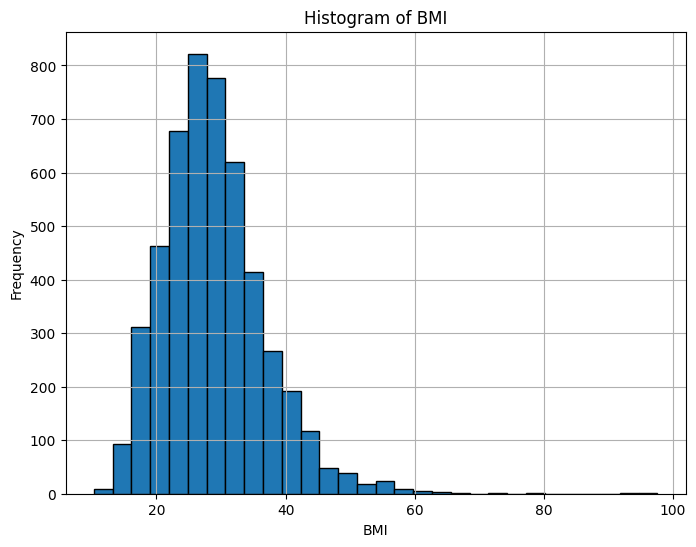

In [ ]:
import matplotlib.pyplot as plt

#ovom linijom odredjujemo sirinu i visinu grafika, sirina=8, visina=6
plt.figure(figsize=(8, 6))
df['bmi'].hist(bins=30, edgecolor='black')
plt.title('Histogram of BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

***Objasnjenje grafika***

X-osa nam predstavlja vrednosti BMI, dok y-osa predstavlja ucestalost tih vrednosti u podacima
Ovaj histogram pokazuje da vecini ljudi BMI lezi izmedju 20 i 40, medjutim manji broj ljudi ima BMI veci od 40 sto predstavlja ***DESNU ASIMETRIJU***

**Desna asimetrija** - histogram se proteze u desno sa manjim frekvencijama na visim vrednostima, visoke vrednosti BMI su prisutne ali u manjem broju.


**U ovom slucaju koristicemo median.**

***Mean funkcija*** - predstavlja aritmeticku sredinu, tj ona racuna prosecnu vrednost skupa podataka. Osetljiva je na outliere kojih ovde ima sa desne strane
Koristi se kada su podaci simetricni

***Median funkcija*** - kada se koristi ova funkcija u pandasu ona sama sortuje vrednosti, tako da manuelno sortiranje nije potrebno. Funkcija odredjuje koja je vrednost u sredini ukoliko imamo neparan broj vrednosti ili prosek dve vrednosti u sredini ukoliko je paran broj vrednosti. Nije osetljiva na outliere kao mean. Koristi se i kod asimetricni.

In [ ]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)

print(df.isnull().sum())


id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
age_group            0
dtype: int64


### ***Pregled kako kategoricke i binarne vrednosti uticu na stroke***

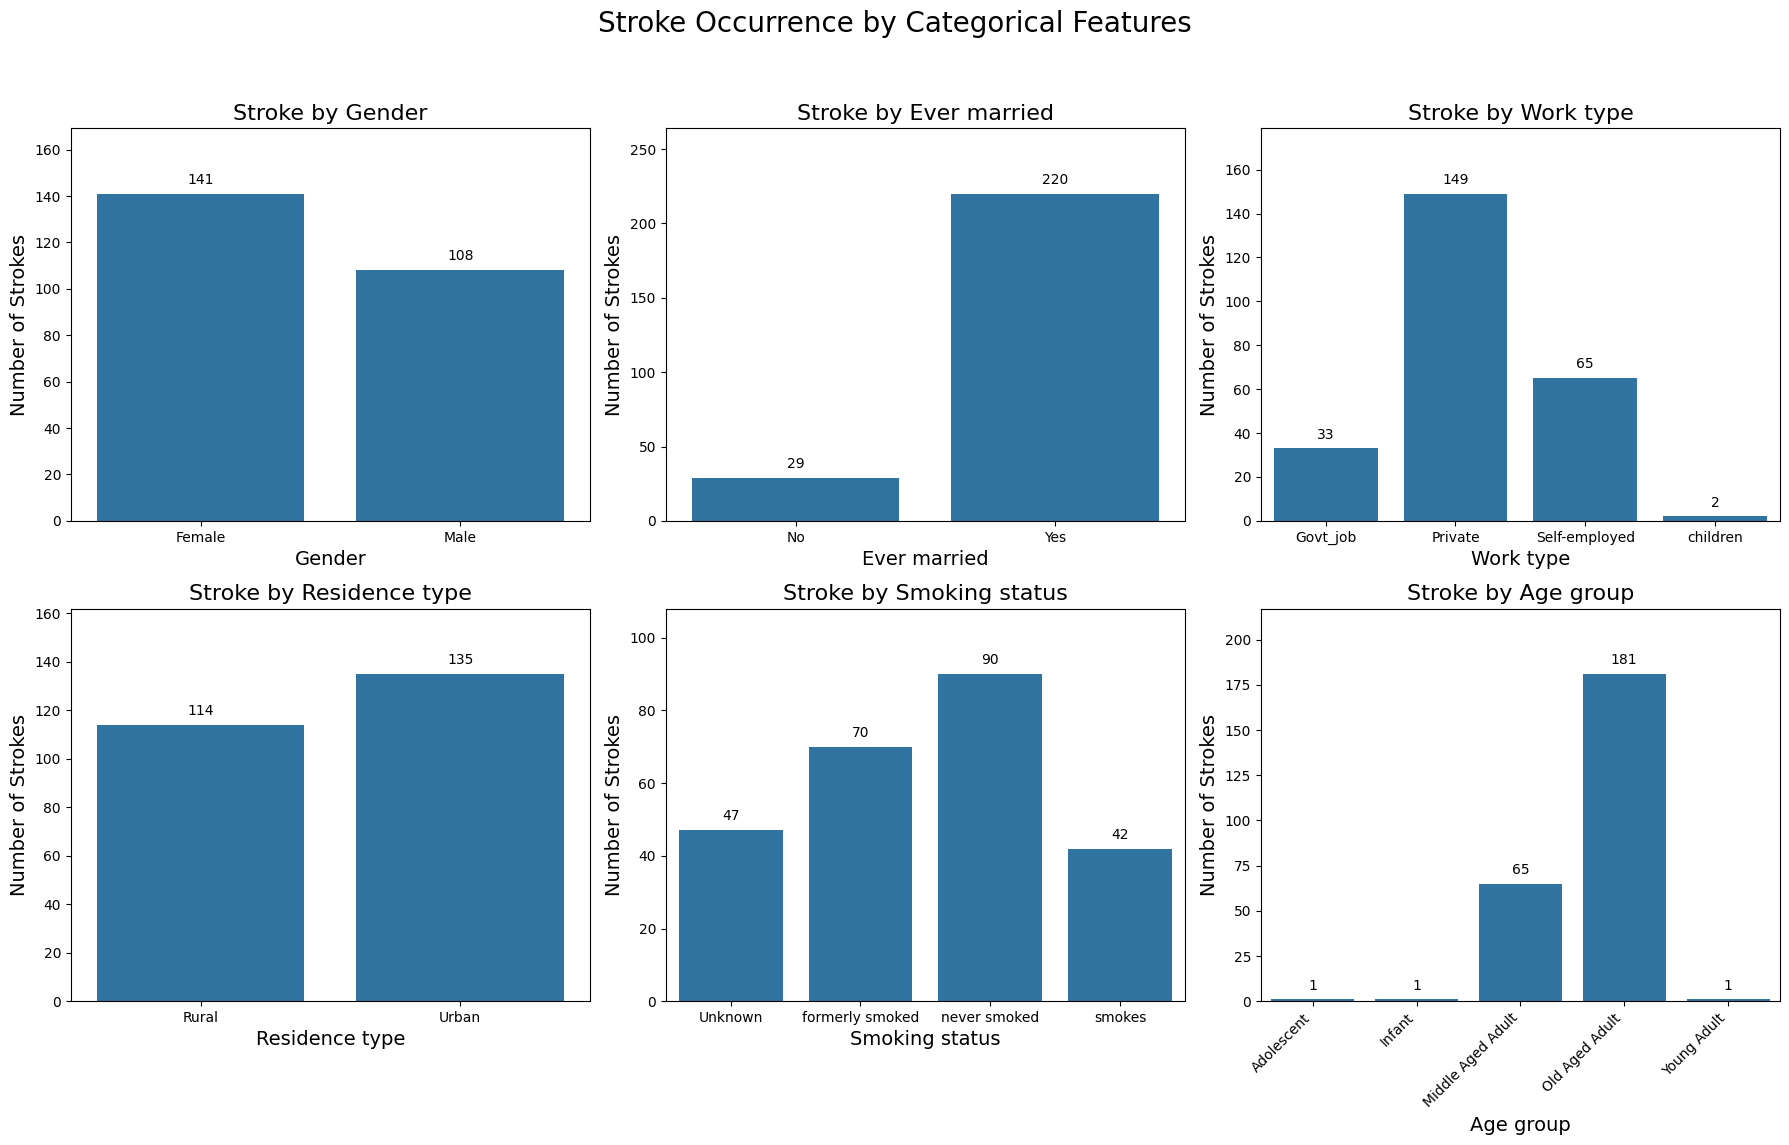

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to visualize against stroke, including age_group
columns_to_plot = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status', 'age_group']

# Set up the plot grid
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))
fig.suptitle('Stroke Occurrence by Categorical Features', fontsize=20)

# Plotting each column
for ax, column in zip(axes.flatten(), columns_to_plot):
    # Group by the column and count strokes
    stroke_counts = df[df['stroke'] == 1][column].value_counts().sort_index()

    # Plot using the category names as x-ticks
    sns.barplot(x=stroke_counts.index, y=stroke_counts.values, ax=ax)
    ax.set_title(f'Stroke by {column.capitalize().replace("_", " ")}', fontsize=16)
    ax.set_xlabel(column.capitalize().replace("_", " "), fontsize=14)
    ax.set_ylabel('Number of Strokes', fontsize=14)
    ax.grid(False)

    # Set y-limit to give space for the annotations
    ax.set_ylim(0, stroke_counts.max() * 1.2)

    # Annotate the bars with the stroke counts
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 10),
                   textcoords = 'offset points')

    # Rotate x-ticks for better readability using plt.xticks
    plt.xticks(rotation=45, ha="right")

# Remove the last empty subplot if columns_to_plot is less than grid slots
if len(columns_to_plot) < len(axes.flatten()):
    fig.delaxes(axes.flatten()[-1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


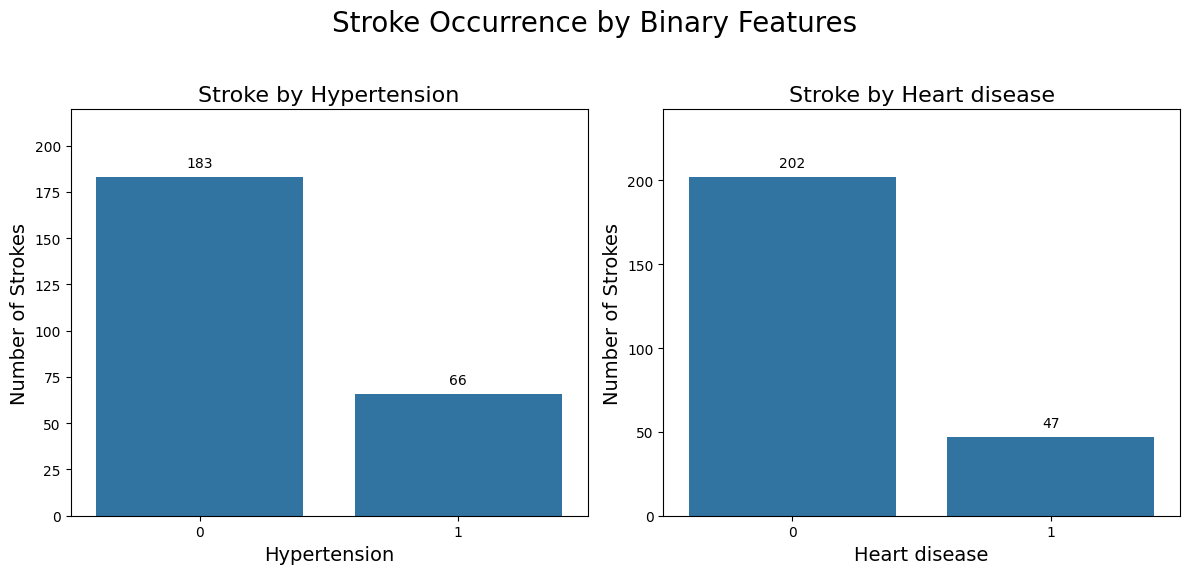

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of binary columns to visualize against stroke
binary_columns_to_plot = ['hypertension', 'heart_disease']

# Set up the plot grid
fig, axes = plt.subplots(nrows=1, ncols=len(binary_columns_to_plot), figsize=(12, 6))
fig.suptitle('Stroke Occurrence by Binary Features', fontsize=20)

# Plotting each binary column
for ax, column in zip(axes.flatten(), binary_columns_to_plot):
    # Group by the column and count strokes
    stroke_counts = df[df['stroke'] == 1][column].value_counts().sort_index()

    # Plot using the binary values (0 and 1) as x-ticks
    sns.barplot(x=stroke_counts.index, y=stroke_counts.values, ax=ax)
    ax.set_title(f'Stroke by {column.capitalize().replace("_", " ")}', fontsize=16)
    ax.set_xlabel(column.capitalize().replace("_", " "), fontsize=14)
    ax.set_ylabel('Number of Strokes', fontsize=14)
    ax.grid(False)

    # Set y-limit to give space for the annotations
    ax.set_ylim(0, stroke_counts.max() * 1.2)

    # Annotate the bars with the stroke counts
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 10),
                   textcoords = 'offset points')

    # Rotate x-ticks for better readability using plt.xticks
    plt.xticks(rotation=0, ha="center")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### ***Uklanjanje kolona koje nam ne trebaju***

Za id je sigurno da ne utice

In [ ]:
df = df.drop(['id'], axis=1)
print(df.head())

   gender   age  hypertension  heart_disease ever_married      work_type  \
0    Male  67.0             0              1          Yes        Private   
1  Female  61.0             0              0          Yes  Self-employed   
2    Male  80.0             0              1          Yes        Private   
3  Female  49.0             0              0          Yes        Private   
4  Female  79.0             1              0          Yes  Self-employed   

  Residence_type  avg_glucose_level   bmi   smoking_status  stroke  \
0          Urban             228.69  36.6  formerly smoked       1   
1          Rural             202.21  28.1     never smoked       1   
2          Rural             105.92  32.5     never smoked       1   
3          Urban             171.23  34.4           smokes       1   
4          Rural             174.12  24.0     never smoked       1   

           age_group  
0     Old Aged Adult  
1     Old Aged Adult  
2     Old Aged Adult  
3  Middle Aged Adult  
4     O

### ***Detekcija anomalija***

Detektujem anomalije samo za ove kolone jer kada sam ih primenila sa ovom tehnikom na kolone koje imaju binarne vrednosti ili na kategoricke kolone koje su pretvorene u int. Kada imam takve vrednosti 0/1 onda IQR moze da bude veoma mali ili 0, cime se dobija nepravilna identifikacija anomalija.

IQR metoda

In [ ]:
#PRVI NACIN IQR

continuous_features = ['age', 'avg_glucose_level', 'bmi']

for feature in continuous_features:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    # Define upper and lower bounds for outliers, OVO SAM MENJAALA KAO ILI 1.0 ILI 1.5
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR



    #Calculate the mean value for replacement
    mean_value = df[feature].mean()

    # Replace outliers with the mean value
    df[feature] = df[feature].apply(lambda x: mean_value if x < lower_bound or x > upper_bound else x)

    # Print replaced outliers for inspection
    replaced_outliers = (df[feature] == mean_value)
    if replaced_outliers.any():
        print(f"Outliers replaced in feature '{feature}':")
        print(df[replaced_outliers])



    """# Remove rows where the feature value is an outlier
    df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]

print("Remaining data shape after removing anomalies:", df.shape)"""


Outliers replaced in feature 'avg_glucose_level':
      gender   age  hypertension  heart_disease ever_married      work_type  \
0       Male  67.0             0              1          Yes        Private   
1     Female  61.0             0              0          Yes  Self-employed   
3     Female  49.0             0              0          Yes        Private   
4     Female  79.0             1              0          Yes  Self-employed   
5       Male  81.0             0              0          Yes        Private   
...      ...   ...           ...            ...          ...            ...   
5061    Male  41.0             0              0          Yes        Private   
5062  Female  82.0             0              0          Yes  Self-employed   
5063    Male  39.0             0              0          Yes        Private   
5064    Male  70.0             0              0          Yes  Self-employed   
5076  Female  34.0             0              0          Yes        Private   

 

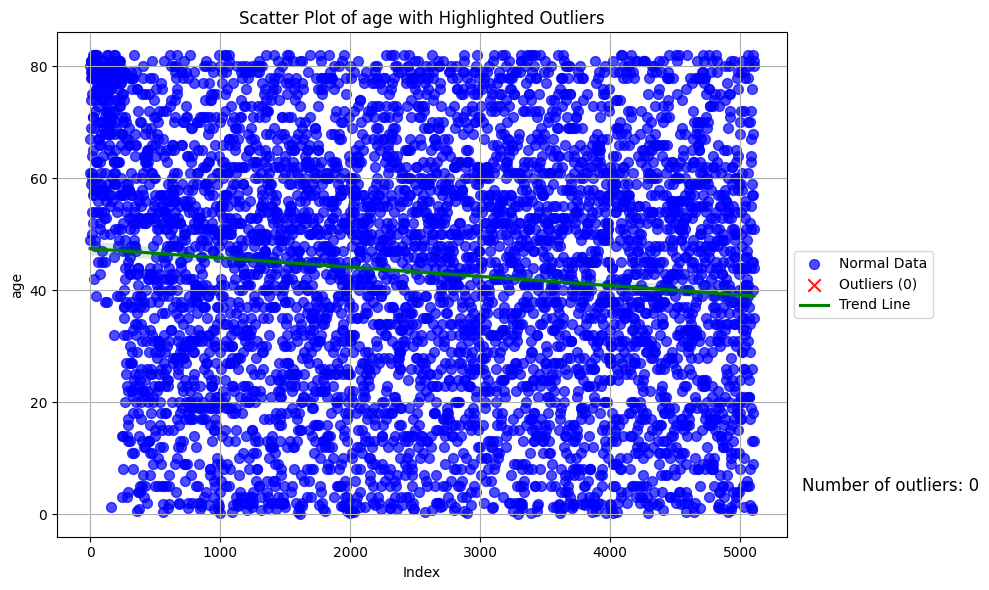

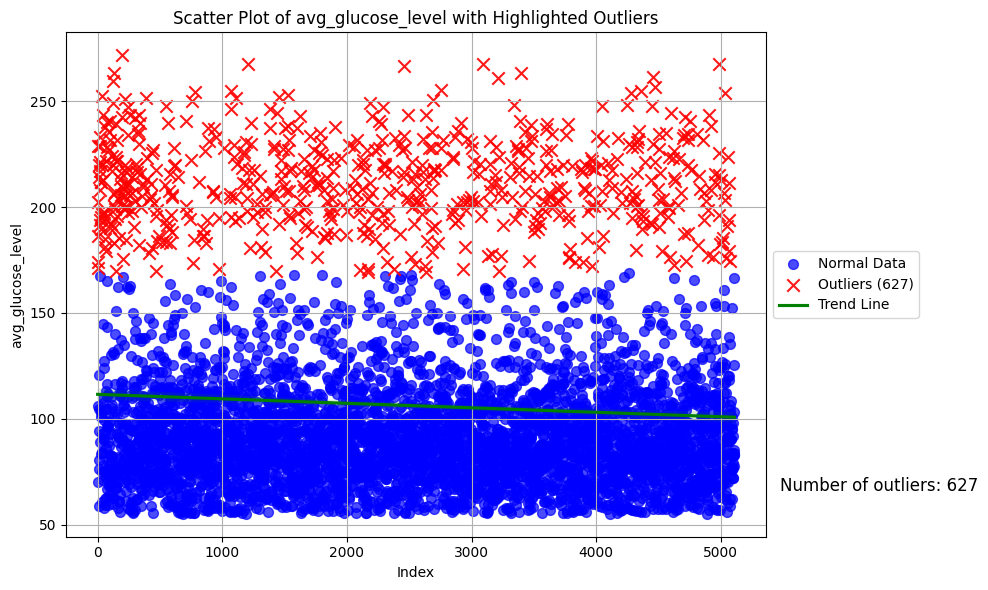

Outliers replaced in feature 'avg_glucose_level':
      gender   age  hypertension  heart_disease ever_married      work_type  \
0       Male  67.0             0              1          Yes        Private   
1     Female  61.0             0              0          Yes  Self-employed   
3     Female  49.0             0              0          Yes        Private   
4     Female  79.0             1              0          Yes  Self-employed   
5       Male  81.0             0              0          Yes        Private   
...      ...   ...           ...            ...          ...            ...   
5061    Male  41.0             0              0          Yes        Private   
5062  Female  82.0             0              0          Yes  Self-employed   
5063    Male  39.0             0              0          Yes        Private   
5064    Male  70.0             0              0          Yes  Self-employed   
5076  Female  34.0             0              0          Yes        Private   

 

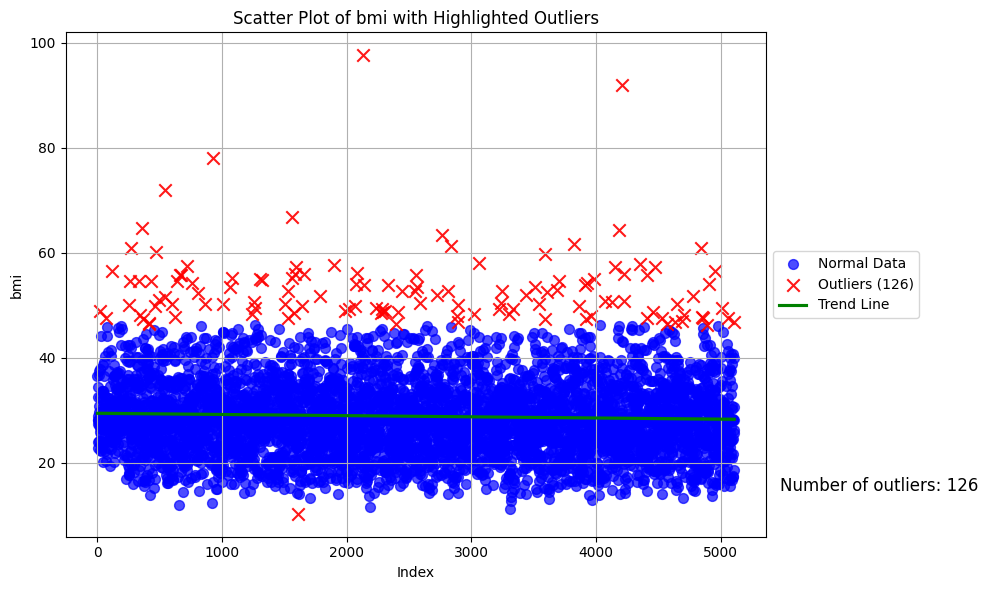

Outliers replaced in feature 'bmi':
      gender   age  hypertension  heart_disease ever_married      work_type  \
21    Female  52.0             1              0          Yes  Self-employed   
66    Female  70.0             0              0          Yes        Private   
113   Female  45.0             0              0          Yes        Private   
254   Female  47.0             0              0          Yes        Private   
258   Female  74.0             1              0          Yes  Self-employed   
...      ...   ...           ...            ...          ...            ...   
4906  Female  53.0             0              0          Yes        Private   
4952    Male  51.0             1              0          Yes  Self-employed   
5009  Female  50.0             0              0          Yes  Self-employed   
5057  Female  49.0             0              0          Yes       Govt_job   
5103  Female  18.0             0              0           No        Private   

     Residence_

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

continuous_features = ['age', 'avg_glucose_level', 'bmi']

for feature in continuous_features:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1

    # Define upper and lower bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Scatter plot with different markers and colors for outliers
    plt.figure(figsize=(10, 6))

    # Plot normal data points
    normal_data = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]
    plt.scatter(normal_data.index, normal_data[feature], label='Normal Data', color='blue', s=50, alpha=0.7)

    # Highlight the outliers
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    plt.scatter(outliers.index, outliers[feature], label=f'Outliers ({len(outliers)})', color='red', s=80, marker='x', alpha=0.9)

    # Optional: Add a regression line to show the trend
    sns.regplot(x=df.index, y=df[feature], scatter=False, color='green', label='Trend Line')

    # Adjust the title and axis labels
    plt.title(f'Scatter Plot of {feature} with Highlighted Outliers')
    plt.xlabel('Index')
    plt.ylabel(f'{feature}')

    # Place the legend outside the plot
    plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

    # Add the number of outliers to the plot
    plt.text(1.02, 0.1, f'Number of outliers: {len(outliers)}', ha='left', va='center', transform=plt.gca().transAxes, fontsize=12)

    # Show the grid and the plot
    plt.grid(True)
    plt.tight_layout()  # This ensures the plot fits nicely
    plt.show()

    # Calculate the mean value for replacement
    mean_value = df[feature].mean()

    # Replace outliers with the mean value
    df[feature] = df[feature].apply(lambda x: mean_value if x < lower_bound or x > upper_bound else x)

    # Print replaced outliers for inspection
    replaced_outliers = (df[feature] == mean_value)
    if replaced_outliers.any():
        print(f"Outliers replaced in feature '{feature}':")
        print(df[replaced_outliers])

# Optionally, you can remove the outliers instead of replacing them
# df = df[(df[feature] >= lower_bound) & (df[feature] <= upper_bound)]


### ***Pregled kako numericke vrednosti uticu na stroke***

<ipython-input-14-e47390db8385>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df['stroke'], y=df[column], ax=axes[i, 2], palette="muted")
<ipython-input-14-e47390db8385>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df['stroke'], y=df[column], ax=axes[i, 2], palette="muted")
<ipython-input-14-e47390db8385>:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df['stroke'], y=df[column], ax=axes[i, 2], palette="muted")


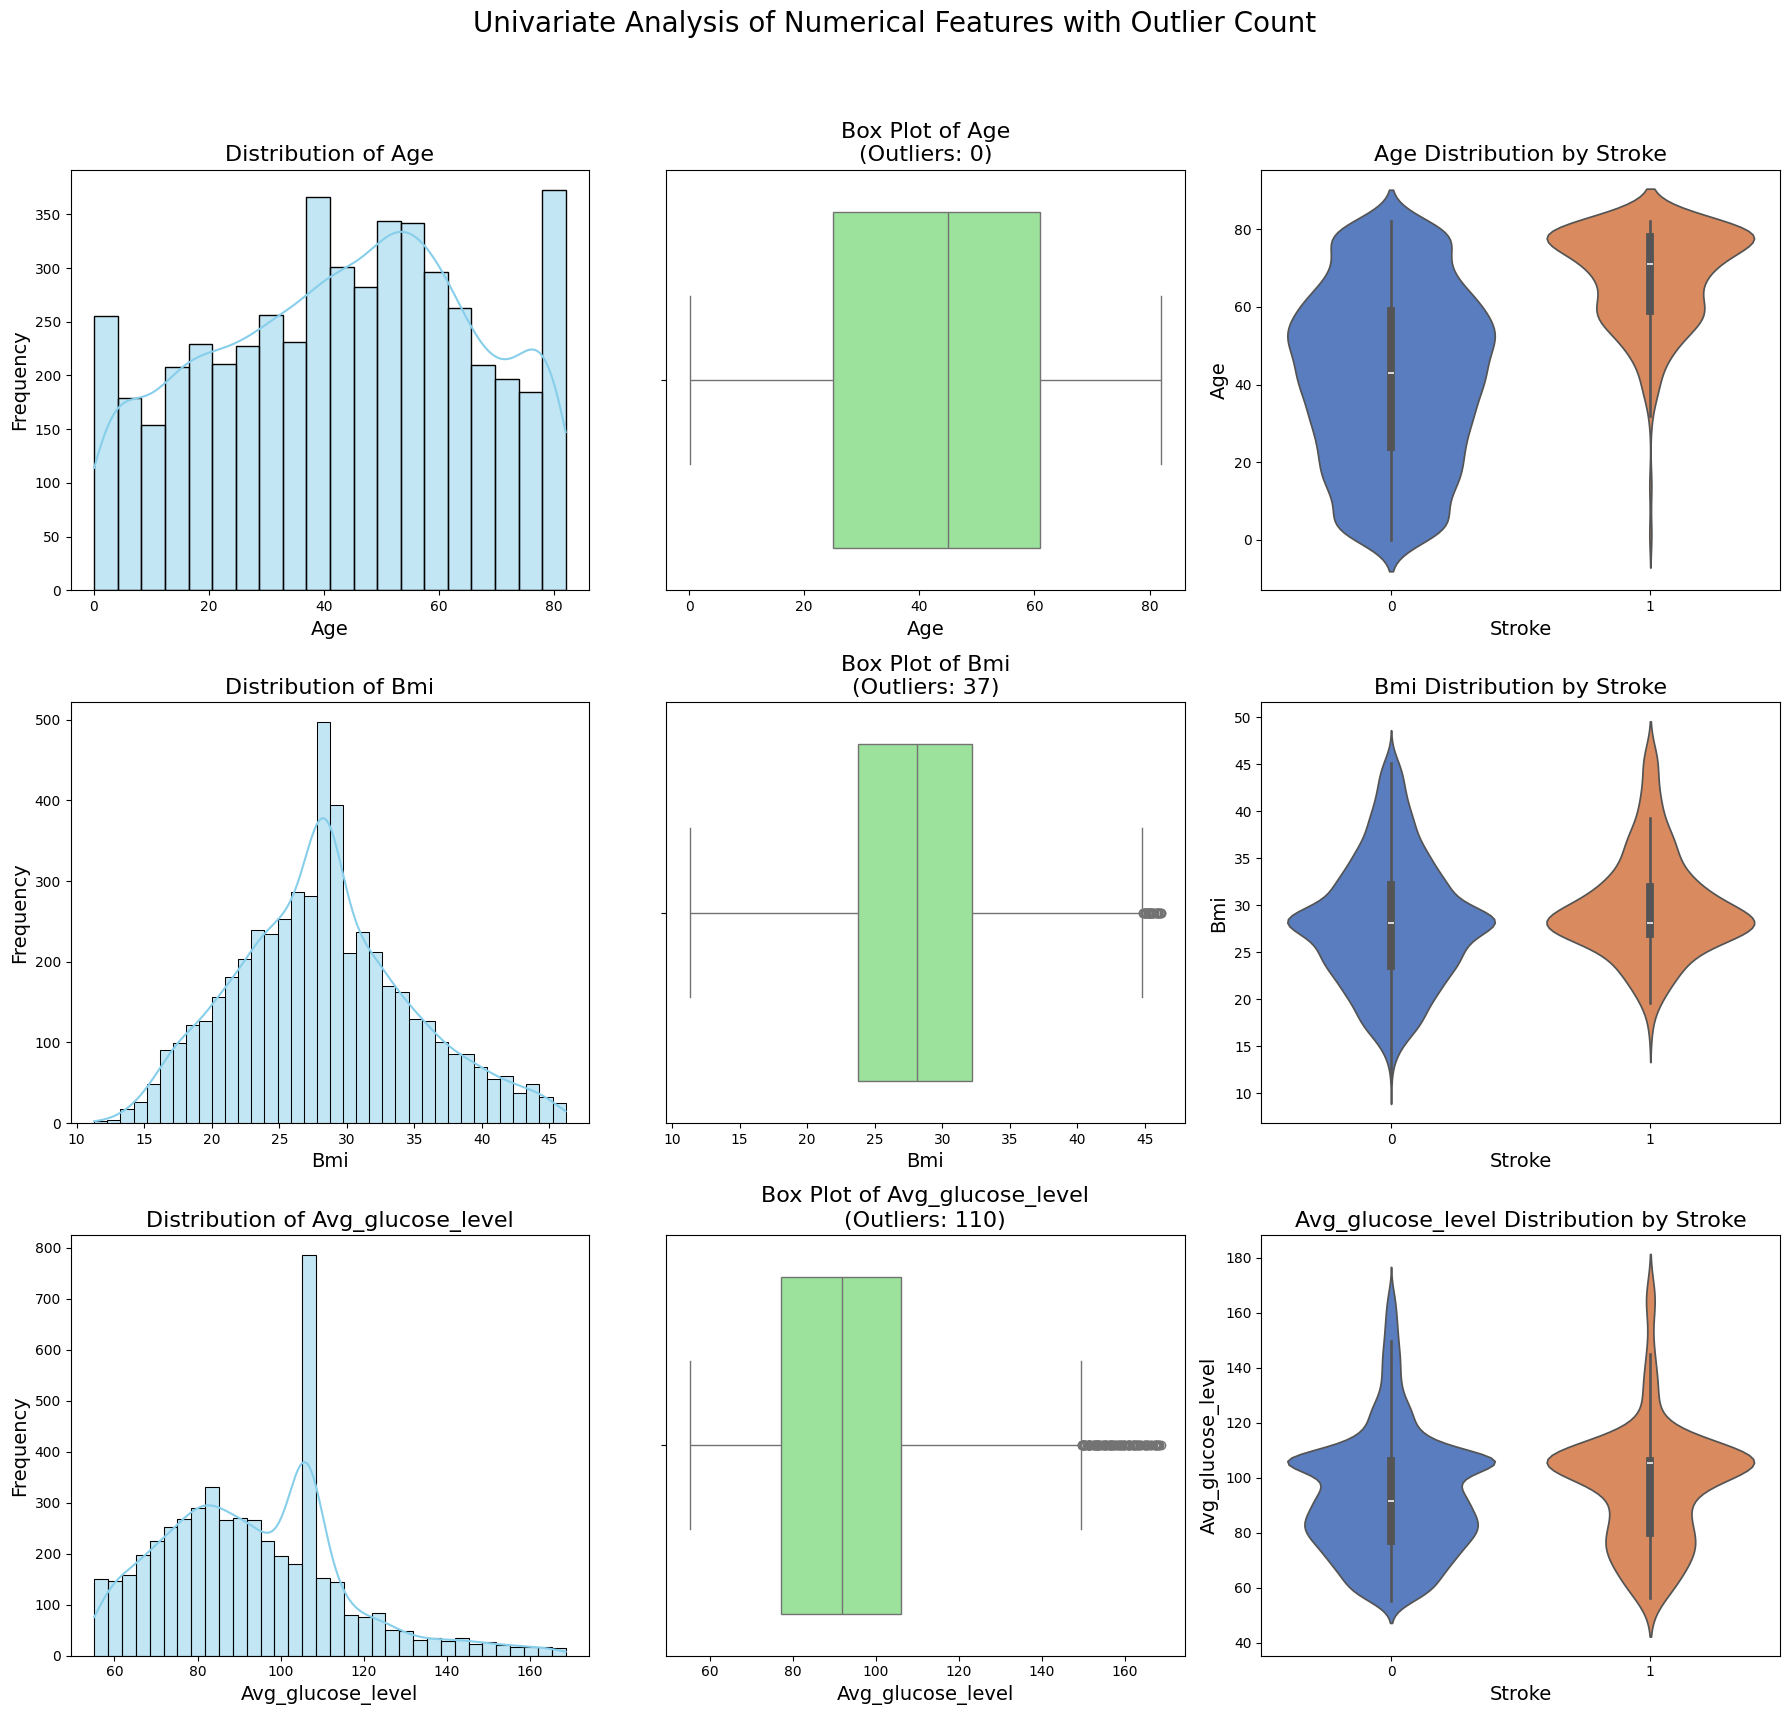

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to analyze
numerical_columns = ['age', 'bmi', 'avg_glucose_level']

# Set up the plot grid
fig, axes = plt.subplots(nrows=len(numerical_columns), ncols=3, figsize=(18, 6 * len(numerical_columns)))
fig.suptitle('Univariate Analysis of Numerical Features with Outlier Count', fontsize=20)

for i, column in enumerate(numerical_columns):
    # Calculate IQR and outliers
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = ((df[column] < lower_bound) | (df[column] > upper_bound)).sum()

    # Distribution plot (Histogram + KDE)
    sns.histplot(df[column], kde=True, ax=axes[i, 0], color="skyblue")
    axes[i, 0].set_title(f'Distribution of {column.capitalize()}', fontsize=16)
    axes[i, 0].set_xlabel(column.capitalize(), fontsize=14)
    axes[i, 0].set_ylabel('Frequency', fontsize=14)

    # Box plot to detect outliers
    sns.boxplot(x=df[column], ax=axes[i, 1], color="lightgreen")
    axes[i, 1].set_title(f'Box Plot of {column.capitalize()}\n(Outliers: {outliers})', fontsize=16)
    axes[i, 1].set_xlabel(column.capitalize(), fontsize=14)

    # Violin plot to show distribution with stroke data
    sns.violinplot(x=df['stroke'], y=df[column], ax=axes[i, 2], palette="muted")
    axes[i, 2].set_title(f'{column.capitalize()} Distribution by Stroke', fontsize=16)
    axes[i, 2].set_xlabel('Stroke', fontsize=14)
    axes[i, 2].set_ylabel(column.capitalize(), fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


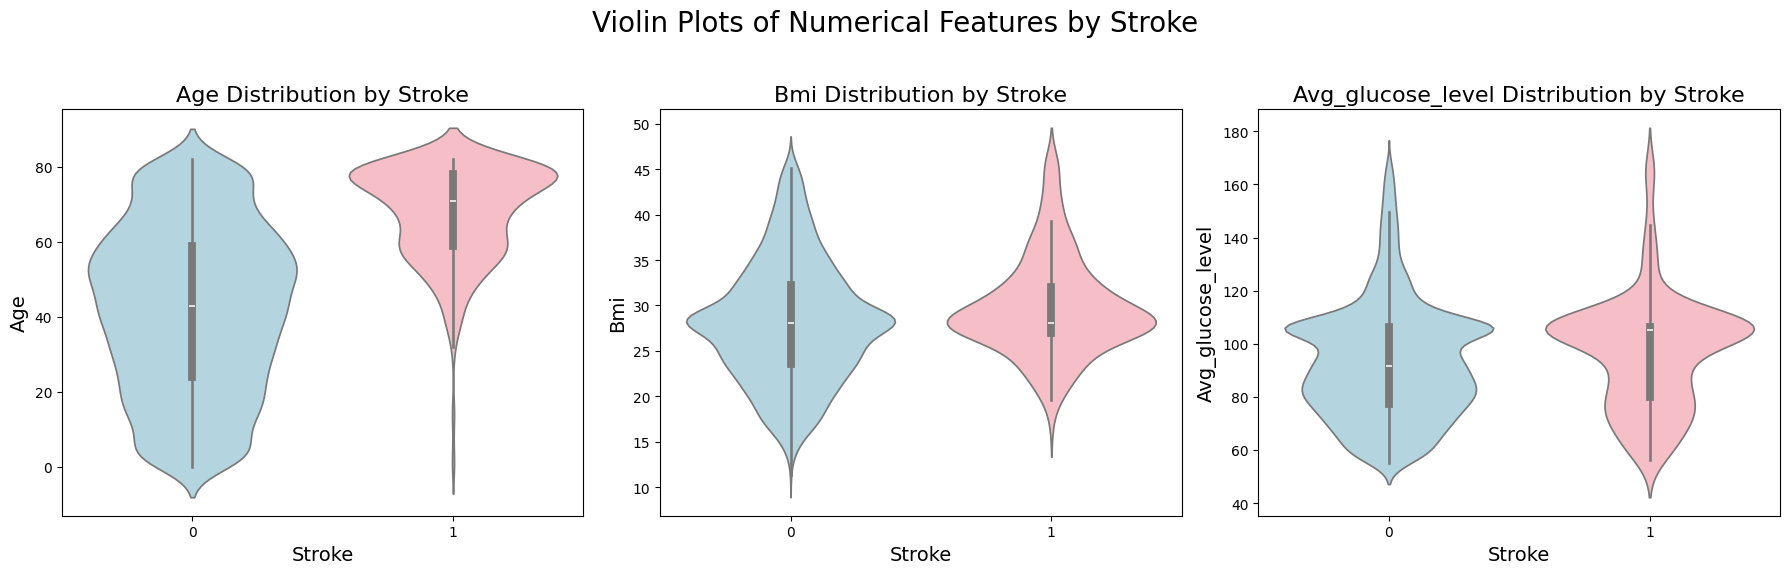

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of numerical columns to analyze
numerical_columns = ['age', 'bmi', 'avg_glucose_level']

# Set up the plot grid for violin plots (1 row, 3 columns)
fig, axes = plt.subplots(nrows=1, ncols=len(numerical_columns), figsize=(18, 6))
fig.suptitle('Violin Plots of Numerical Features by Stroke', fontsize=20)

# Boje za stroke = 0 (svetlo plava) i stroke = 1 (svetlo roza)
palette = {0: '#ADD8E6', 1: '#FFB6C1'}  # Svetlo plava za no-stroke, svetlo roza za stroke

for i, column in enumerate(numerical_columns):
    # Violin plot to show distribution with stroke data, using 'hue' for color mapping
    sns.violinplot(x='stroke', y=column, data=df, ax=axes[i], hue='stroke', palette=palette, dodge=False)
    axes[i].set_title(f'{column.capitalize()} Distribution by Stroke', fontsize=16)
    axes[i].set_xlabel('Stroke', fontsize=14)
    axes[i].set_ylabel(column.capitalize(), fontsize=14)

# Uklanjamo duplirane legende
for ax in axes:
    ax.get_legend().remove()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


***Objasnjenje grafika***

***AGE***

***Histogram*** pokazuje kako su godine rasporedjene u datasetu. Visina svakog tog bar-a predstavlja broj ljudi koji ima godine u tom opsegu.

***KDE linija(Kernel Density Estimate)*** gustina verovatnoce godina u datasetu.

U ovom slucaju distribucija godina pocinje od vrlo malih (0 godina) do veoma starih(80 godina), a raspodela je generalno ravnomerna za ljude izmedju 20-60 godna, ali je veca koncentracija izmedju 50 i 60 godina.


***Violin plot*** prikazuje nam gustinu podataka na razlicitim vrednostima. Sirina prikazuje gustinu uzoraka na toj odredjenoj godini. Levi deo ili leva violina nam pokazuje distribuciju ljudi koji nisu imali udar. Desni deo ili desna violina nam pokazuje distribuciju ljudi koji su imali udar. Bela tacka predstavlja medijanu. Debela crna linija prikazuje IQR, koji se proteze od Q1 do Q3, ovde lezi 50% podataka. Tanka crna linije proteze se od najnize do najvise tacke koja ne predstavlja outlier pomnozena sa 1.5 IQR.

Distribucija godina bez udara - Grafik je sirok na razlicitim godinama, ali znacajnije na delu izmedju 50 i 60 godina. Medijana je na oko 45/50 godina, a IQR nam ukazuje na to da 50% ljudi spada u grupu starosti od 35-60 godina.

Distribucija godina sa udarom - Grafik je uzi u odnosu na levi, ovde postoji veca koncentracija izmedju 60 i 80 godina. Ovo ukazuje na to da je udar cesci u ovom starosnom dobu tj kod starjih ljudi.

Medijana je ovde na 70 godina,sto ukazuje na to da je medijana godina u kojima je srcani udar cesci znatno veca od onih u kojima nije.

IQR ukazuje na to da 50% ljudi koji su imali udar spada u grupu od 60-75 godina.

***ZAKLJUČAK***

Rizik od srcanog udara se povecava sa godinama. Vecina ljudi koji su imali srcani udar su izmadju 60-80. I medijana kao sto je vec receno je visa u slucajevima koji su imali srcani udar.

Grupa ljudi koji nisu imali srcani udar ima mnogo siri raspon godina sa vecom gustinom u opsegu od malo godina do srednjih godina, sto ukazuje na cinjenicu da je srcani udar redji kod mladjih osoba.

Oblik violine nam pokazuje da su godine vazan faktor u proceni srcanog udara, zbog cinjenice da grafik pokazuje da stariji ljudi imaju vece sanse da dobiju srcani udar.


***BMI***

***Histogram*** - vecina ljudi ima BMI izmedju 20 i 35, sa peakom na 28-30. Distribucija je donekle na desno sto nam govori da ima malo ljudi koji imaju visi BMI. Nakon detekcije anomalija vecina ljudi ima normalan ili malo povecan BMI, dok je ostalo outliera koji imaju veci BMI, ali ne bi ih trebalo sve uklanjati zbog gubitka podataka i jer su to opet neke realne slike pacijenata koje su moguce.

***Violin plot*** - Kao i na histogramu u levom delu grafika vidimo da je najsiri na delu gde je BMI izmedju 20,25/30 a da je medijana na 28. Desni deo grafika pokazuje da je on za nijansu uzi od levog ali da je medijana i dalje na oko 28-30. Ali se primeti da je koncentracija najveca na 30.


***ZAKLJUCAK***

BMI kod ljudi koji su imali srcani udar je za nijansu visi u proseku od onog kod ljudi koji nisu imali srcani udar, ali to nije toliko velika razlika da bi se reklo da direktno utice na srcani udar. BMI mozda jeste faktor u predikciji srcanog udara ali ne znacajan faktor kao sto su na primer godine.



***AVG_GLUCOSE_LEVEL***


***Histogram*** - Vecina pojedinaca ima prosecan nivo secera u krvi u opsegu od 60-120, sa peakom na 100.

Desna asimetrija, sto znaci da ima znacajan broj pojedinaca koji imaju nizi nivo glukoze u krvi, ali postoje i oni koji imaju vise nivoe. Kao i kod BMI nakon detekcije anomalija vecina njih je uklonjena, medjutim postoji i dalje odredjen broj, jer se ne mogu sve ukloniti radi prikaza realne situacije, jer jeste moguce da neki pacijenti imaju ekstremno visok nivo secera.



***Violin plot*** - levi grafik nam pokazuje da vecina pojedinaca ima nivo secera u krvi izmedju 60-120 kao na histogramu a da je medijana na 100. Desni grafik je uzi od levog sa vecom koncentracijom oko 100-130. Medijana u ovom delu je za nijansu visa, sto znaci da ljudi koji imaju srcani udar imaju nesto veci nivo secera u krvi od onih koji nemaju, takodje postoji rep koji ide ka visim nivoima glukoze u krvi.

***ZAKLJUCAK***

Grafici nam ukazuju na to da pojedinci koji su imali srcani udar imaju veci nivo secera u krvi od onih koji nisu. Ovo nam moze reci da povecani nivoi glukoze mogu da povecaju rizik za dobijanjem srcanog udara.



### VIZUELIZACIJA

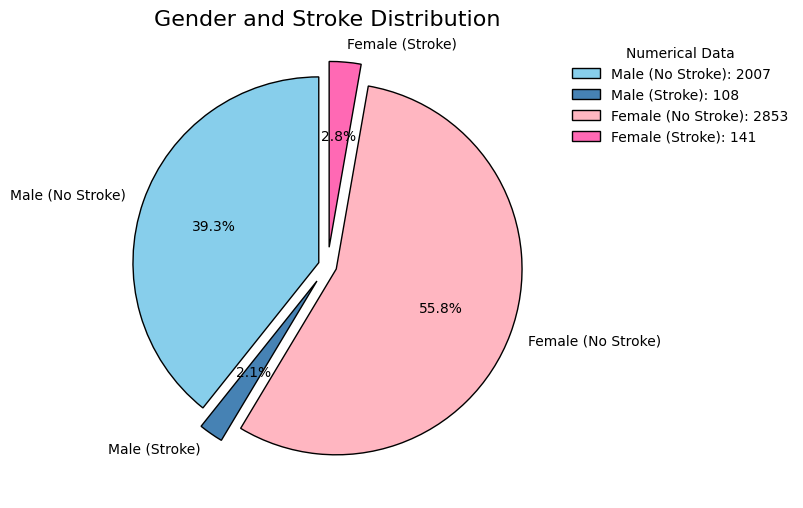

In [ ]:
import matplotlib.pyplot as plt

# Pretpostavljam da je u DataFrame-u 'df' kolona 'gender' i kolona 'stroke' već dostupna

# Brojanje ukupnog broja muškaraca i žena
gender_counts = df['gender'].value_counts()

# Brojanje broja muškaraca i žena koji su imali moždani udar
stroke_counts = df[df['stroke'] == 1]['gender'].value_counts()

# Priprema podataka za pie chart
male_count = gender_counts['Male']
female_count = gender_counts['Female']
male_stroke_count = stroke_counts.get('Male', 0)
female_stroke_count = stroke_counts.get('Female', 0)

# Kreiramo podatke za prikazivanje
data = [male_count - male_stroke_count, male_stroke_count, female_count - female_stroke_count, female_stroke_count]
labels = ['Male (No Stroke)', 'Male (Stroke)', 'Female (No Stroke)', 'Female (Stroke)']
colors = ['#87CEEB', '#4682B4', '#FFB6C1', '#FF69B4']

# Kreiranje pie chart sa eksplodiranjem (odvajanjem) delova pite za bolji pregled
explode = (0.05, 0.1, 0.05, 0.1)

plt.figure(figsize=(8, 8))
plt.pie(data, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors, explode=explode, wedgeprops={'edgecolor': 'black'})

# Dodavanje ispravne legende sa detaljima o muškarcima i ženama, uključujući broj moždanih udara
plt.legend([f"Male (No Stroke): {male_count - male_stroke_count}",
            f"Male (Stroke): {male_stroke_count}",
            f"Female (No Stroke): {female_count - female_stroke_count}",
            f"Female (Stroke): {female_stroke_count}"],
           loc='upper left', bbox_to_anchor=(1, 1), title="Numerical Data", frameon=False)

# Naslov
plt.title('Gender and Stroke Distribution', fontsize=16)

# Prikaz grafika sa zbijenim layout-om
plt.tight_layout()
plt.show()


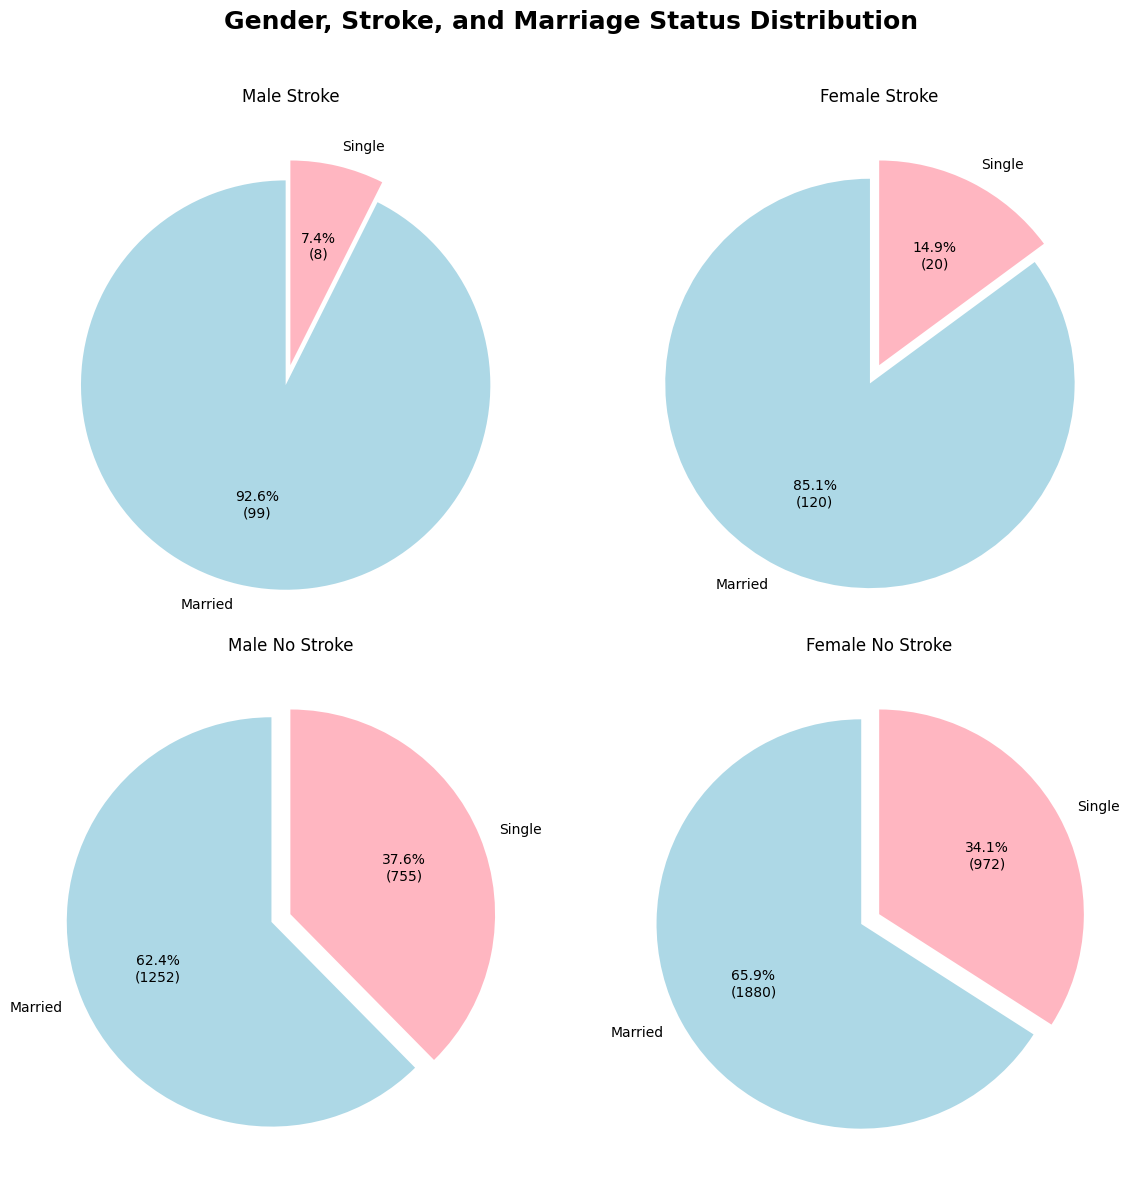

In [ ]:
import matplotlib.pyplot as plt

# Pretpostavljam da je u DataFrame-u 'df' kolona 'gender', 'stroke', i 'ever_married' (Yes/No)

# Grupisanje podataka po polu, moždanom udaru i bračnom statusu
male_stroke_married = df[(df['gender'] == 'Male') & (df['stroke'] == 1) & (df['ever_married'] == 'Yes')].shape[0]
male_stroke_single = df[(df['gender'] == 'Male') & (df['stroke'] == 1) & (df['ever_married'] == 'No')].shape[0]
female_stroke_married = df[(df['gender'] == 'Female') & (df['stroke'] == 1) & (df['ever_married'] == 'Yes')].shape[0]
female_stroke_single = df[(df['gender'] == 'Female') & (df['stroke'] == 1) & (df['ever_married'] == 'No')].shape[0]

male_no_stroke_married = df[(df['gender'] == 'Male') & (df['stroke'] == 0) & (df['ever_married'] == 'Yes')].shape[0]
male_no_stroke_single = df[(df['gender'] == 'Male') & (df['stroke'] == 0) & (df['ever_married'] == 'No')].shape[0]
female_no_stroke_married = df[(df['gender'] == 'Female') & (df['stroke'] == 0) & (df['ever_married'] == 'Yes')].shape[0]
female_no_stroke_single = df[(df['gender'] == 'Female') & (df['stroke'] == 0) & (df['ever_married'] == 'No')].shape[0]

# Podešavanje podataka za četiri pie chart-a
labels_stroke = ['Married', 'Single']
colors = ['#ADD8E6', '#FFB6C1']  # Svetlo plava i svetlo roza boja

# Funkcija za prikazivanje brojčane i procentualne vrednosti
def autopct_with_values(pct, total):
    absolute = int(pct/100.*total)
    return f'{pct:.1f}%\n({absolute})'

# Kreiranje figure i plot-ova
fig, axs = plt.subplots(2, 2, figsize=(12, 12))

# Plot 1: Male Stroke
total_male_stroke = male_stroke_married + male_stroke_single
axs[0, 0].pie([male_stroke_married, male_stroke_single], labels=labels_stroke,
              autopct=lambda pct: autopct_with_values(pct, total_male_stroke), colors=colors,
              startangle=90, explode=(0.1, 0))
axs[0, 0].set_title('Male Stroke')

# Plot 2: Female Stroke
total_female_stroke = female_stroke_married + female_stroke_single
axs[0, 1].pie([female_stroke_married, female_stroke_single], labels=labels_stroke,
              autopct=lambda pct: autopct_with_values(pct, total_female_stroke), colors=colors,
              startangle=90, explode=(0.1, 0))
axs[0, 1].set_title('Female Stroke')

# Plot 3: Male No Stroke
total_male_no_stroke = male_no_stroke_married + male_no_stroke_single
axs[1, 0].pie([male_no_stroke_married, male_no_stroke_single], labels=labels_stroke,
              autopct=lambda pct: autopct_with_values(pct, total_male_no_stroke), colors=colors,
              startangle=90, explode=(0.1, 0))
axs[1, 0].set_title('Male No Stroke')

# Plot 4: Female No Stroke
total_female_no_stroke = female_no_stroke_married + female_no_stroke_single
axs[1, 1].pie([female_no_stroke_married, female_no_stroke_single], labels=labels_stroke,
              autopct=lambda pct: autopct_with_values(pct, total_female_no_stroke), colors=colors,
              startangle=90, explode=(0.1, 0))
axs[1, 1].set_title('Female No Stroke')

# Dodavanje glavnog naslova
plt.suptitle('Gender, Stroke, and Marriage Status Distribution', fontsize=18, fontweight='bold')

# Podešavanje rasporeda
plt.tight_layout(rect=[0, 0, 1, 0.96])  # Ostavlja prostor za naslov
plt.show()


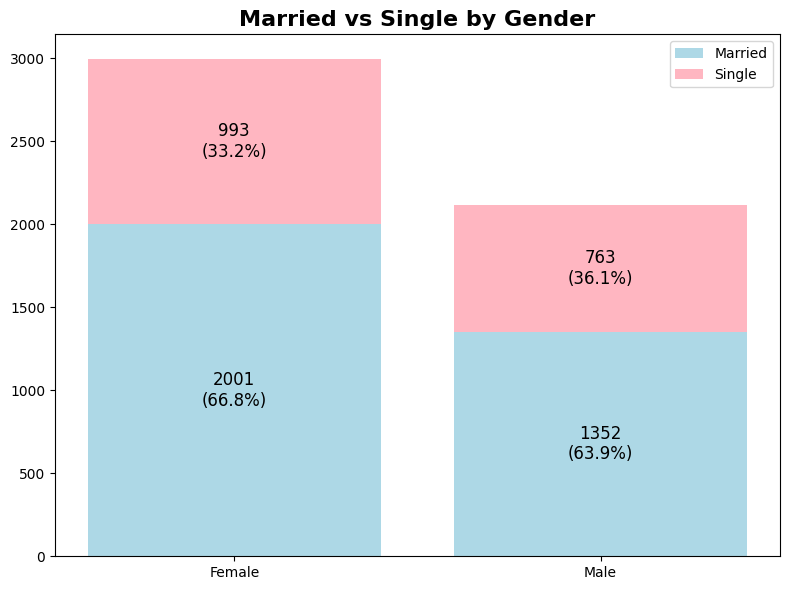

In [ ]:
import matplotlib.pyplot as plt

# Pretpostavljam da je u DataFrame-u 'df' kolona 'gender' i 'ever_married' (Yes/No)

# Grupisanje podataka po polu i bračnom statusu
total_male_married = df[(df['gender'] == 'Male') & (df['ever_married'] == 'Yes')].shape[0]
total_male_single = df[(df['gender'] == 'Male') & (df['ever_married'] == 'No')].shape[0]
total_female_married = df[(df['gender'] == 'Female') & (df['ever_married'] == 'Yes')].shape[0]
total_female_single = df[(df['gender'] == 'Female') & (df['ever_married'] == 'No')].shape[0]

# Boje za bar chart (svetlo plava i svetlo roze, preuzete iz slike)
bar_colors = ['#ADD8E6', '#FFB6C1']  # Svetlo plava za married, svetlo roze za single

# Kreiranje figure i plot-ova
fig, ax = plt.subplots(figsize=(8, 6))

# Bar chart za muškarce i žene
ax.bar(['Female', 'Male'], [total_female_married, total_male_married], color=bar_colors[0], label='Married')
ax.bar(['Female', 'Male'], [total_female_single, total_male_single], bottom=[total_female_married, total_male_married], color=bar_colors[1], label='Single')

# Dodavanje brojeva na bar chart
ax.text(0, total_female_married / 2, f'{total_female_married}\n({total_female_married / (total_female_married + total_female_single) * 100:.1f}%)', ha='center', va='center', color='black', fontsize=12)
ax.text(0, total_female_married + total_female_single / 2, f'{total_female_single}\n({total_female_single / (total_female_married + total_female_single) * 100:.1f}%)', ha='center', va='center', color='black', fontsize=12)
ax.text(1, total_male_married / 2, f'{total_male_married}\n({total_male_married / (total_male_married + total_male_single) * 100:.1f}%)', ha='center', va='center', color='black', fontsize=12)
ax.text(1, total_male_married + total_male_single / 2, f'{total_male_single}\n({total_male_single / (total_male_married + total_male_single) * 100:.1f}%)', ha='center', va='center', color='black', fontsize=12)

# Podešavanje naslova i legende
ax.set_title('Married vs Single by Gender', fontsize=16, fontweight='bold')
ax.legend(loc='upper right')

# Prikaz grafika
plt.tight_layout()
plt.show()


<ipython-input-23-98a2e6a37762>:26: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sns.heatmap(stroke_percentage, annot=stroke_percentage.applymap(annotate_percent), fmt='', cmap=sns.color_palette(heatmap_colors), cbar=False, ax=axs[0], linewidths=0.5, linecolor='white')
<ipython-input-23-98a2e6a37762>:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  sns.heatmap(no_stroke_percentage, annot=no_stroke_percentage.applymap(annotate_percent), fmt='', cmap=sns.color_palette(heatmap_colors), cbar=False, ax=axs[1], linewidths=0.5, linecolor='white')


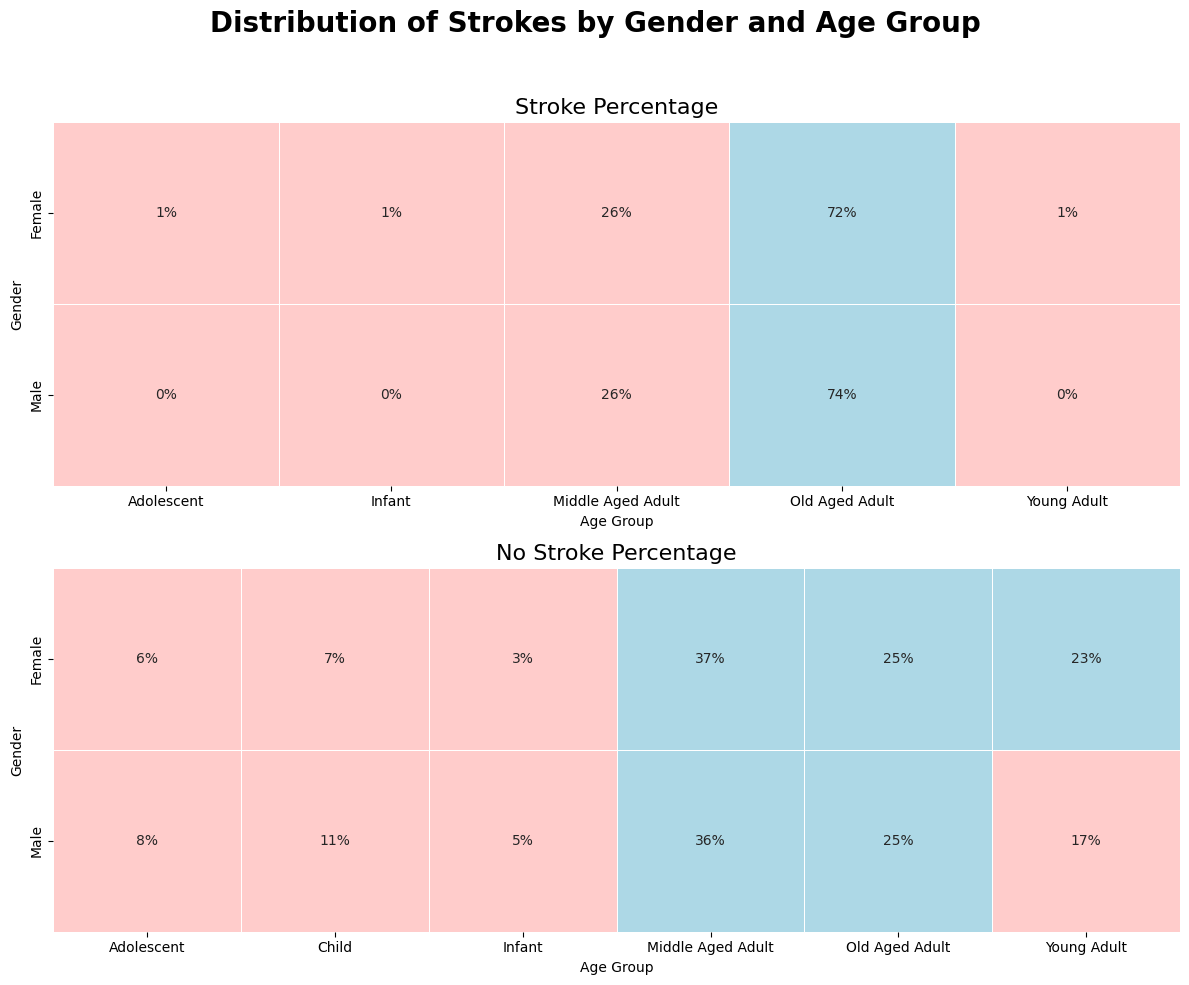

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pretpostavljamo da je DataFrame 'df' već definisan i ima kolone: 'age_group', 'gender', 'stroke'

# Grupišemo podatke prema polu, moždanom udaru i starosnoj grupi
stroke_data = df[df['stroke'] == 1].groupby(['gender', 'age_group']).size().unstack(fill_value=0)
no_stroke_data = df[df['stroke'] == 0].groupby(['gender', 'age_group']).size().unstack(fill_value=0)

# Dodavanje procenta u svaku grupu
stroke_percentage = stroke_data.div(stroke_data.sum(axis=1), axis=0) * 100
no_stroke_percentage = no_stroke_data.div(no_stroke_data.sum(axis=1), axis=0) * 100

# Boje za toplinsku mapu
heatmap_colors = ['#FFCCCB', '#ADD8E6']  # Svetlo crvena i svetlo plava

# Funkcija za prikaz vrednosti sa procentom
def annotate_percent(val):
    return f'{val:.0f}%'

# Kreiranje figure za tabele
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Tabela sa procentima za moždani udar (Stroke)
sns.heatmap(stroke_percentage, annot=stroke_percentage.applymap(annotate_percent), fmt='', cmap=sns.color_palette(heatmap_colors), cbar=False, ax=axs[0], linewidths=0.5, linecolor='white')
axs[0].set_title('Stroke Percentage', fontsize=16)
axs[0].set_xlabel('Age Group')
axs[0].set_ylabel('Gender')

# Plot 2: Tabela sa procentima za bez moždanog udara (No Stroke)
sns.heatmap(no_stroke_percentage, annot=no_stroke_percentage.applymap(annotate_percent), fmt='', cmap=sns.color_palette(heatmap_colors), cbar=False, ax=axs[1], linewidths=0.5, linecolor='white')
axs[1].set_title('No Stroke Percentage', fontsize=16)
axs[1].set_xlabel('Age Group')
axs[1].set_ylabel('Gender')

# Glavni naslov
plt.suptitle('Distribution of Strokes by Gender and Age Group', fontsize=20, fontweight='bold')

# Prikazivanje grafika
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Ostavlja prostor za glavni naslov
plt.show()




---
Organizacija grafikona:
Vodoravno (x-osa): Prikazane su različite starosne grupe (Adolescent, Infant, Middle Aged Adult, Old Aged Adult, Young Adult).
Uspravno (y-osa): Prikazani su polovi:
Gornji red (Female): Rezultati za žene.
Donji red (Male): Rezultati za muškarce.
Gornji grafikon: Stroke Percentage (Procenat osoba sa moždanim udarom)
Roza boja:
Predstavlja procenat žena koje su imale moždani udar u različitim starosnim grupama.
Npr. u starosnoj grupi Old Aged Adult (stari odrasli), 72% žena sa moždanim udarom pripada ovoj grupi.
Plava boja:
Predstavlja procenat muškaraca koji su imali moždani udar u različitim starosnim grupama.
Npr. 74% muškaraca sa moždanim udarom je iz starosne grupe Old Aged Adult.
Donji grafikon: No Stroke Percentage (Procenat osoba bez moždanog udara)
Roza boja:
Predstavlja procenat žena koje nisu imale moždani udar.
Npr. 37% žena bez moždanog udara pripada starosnoj grupi Middle Aged Adult (srednje odrasle osobe).
Plava boja:
Predstavlja procenat muškaraca koji nisu imali moždani udar.
Npr. 36% muškaraca bez moždanog udara pripada starosnoj grupi Middle Aged Adult.
Sumirano:
Gornji red u oba grafikona odnosi se na žene (Female).
Donji red u oba grafikona odnosi se na muškarce (Male).
Roza boja na grafikonu je povezana sa ženama, dok plava boja označava muškarce.
Prvi grafikon prikazuje procente osoba sa moždanim udarom, dok drugi prikazuje procente osoba bez moždanog udara.



### ***Provera tipova podataka i konverzija***

Kada imamo kombinovane datasetove kao sto je to ovde slucaj pre nego sto pretrazimo da li postoje neke anomalije u njemu potrebno je da pretvorimo sve kategoricke vrednosti u numericke

In [ ]:
print('Pre pretvaranja:')
print(df.dtypes)
"""
# Convert object types to categorical codes and bool types to int
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].astype('category').cat.codes.astype('int64')
    elif df[column].dtype == 'bool':
        df[column] = df[column].astype('int64')

print("")
print('Posle pretvaranja:')
print(df.dtypes)"""

from sklearn.preprocessing import LabelEncoder

# Inicijalizacija LabelEncodera
le = LabelEncoder()

# Prolazak kroz kolone i primena LabelEncoder-a na 'object' kolone
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = le.fit_transform(df[column])
    elif df[column].dtype == 'bool':
        df[column] = df[column].astype('int64')

print("")
print('Posle pretvaranja:')
print(df.dtypes)




Pre pretvaranja:
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
age_group             object
dtype: object

Posle pretvaranja:
gender                 int64
age                  float64
hypertension           int64
heart_disease          int64
ever_married           int64
work_type              int64
Residence_type         int64
avg_glucose_level    float64
bmi                  float64
smoking_status         int64
stroke                 int64
age_group              int64
dtype: object


### ***Korelacija***

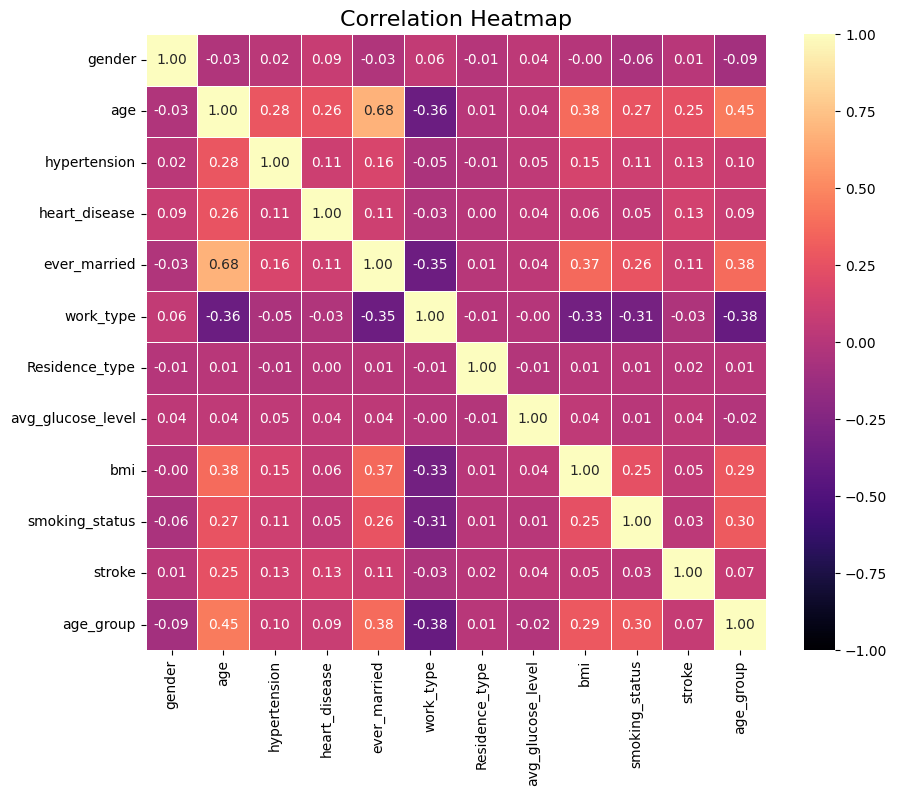

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = df.corr()

# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='magma', linewidths=0.5, vmin=-1, vmax=1)

# Add a title
plt.title('Correlation Heatmap', fontsize=16)

# Display the heatmap
plt.show()


### ***Podela podataka***



Prvo potrebno je importovati train_test_split fju iz scikit-learn biblioteke, kako bi uopste mogli da podelimo podatke

Odredjujemo sta nam predstavlja X( izbacujemo kolonu stroke, a axis = 1 znaci upravo to da se izbacuje kolona a ne vrsta, tako da u X imamo sve ostale kolone) i sta nam predstavlja y(to nam je u stvari target tj ono sto predvidjamo i sastoji se samo od kolone stroke iz dataseta)

X - matrica koja sadrzi sve podatke sem stroke

y - target vektor

test_size = 0.2 - ovo nam pokazuje da ce 20% podataka da se koristi za testiranje a ostalih 80% ce da bude za trening. To je uobicajena podela skupa moze da bude tako 80-20 ili 70-30.

stratify = y - nam odredjuje to da proporcija klasa(npr onih koji su imali srcani udar i onih koji nisu) bude ista u trening i test skupu.

random_state = 42 - da je svaki put ista podela kad pokrenemo kod

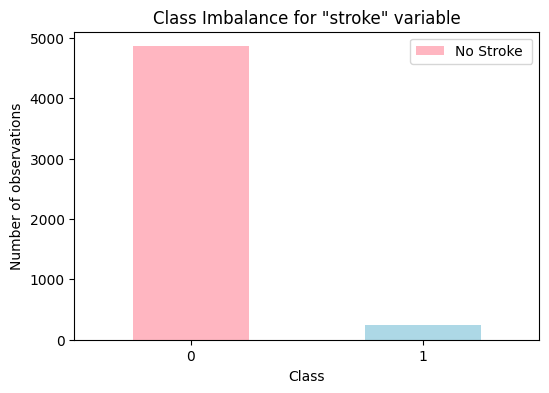

In [ ]:
import matplotlib.pyplot as plt

# Split the data
X = df.drop(['stroke'], axis=1)
y = df['stroke']

# Bar chart for class imbalance
plt.figure(figsize=(6,4))
y.value_counts().plot(kind='bar', color=['lightpink', 'lightblue'])
plt.title('Class Imbalance for "stroke" variable')
plt.xlabel('Class')
plt.ylabel('Number of observations')
plt.xticks(rotation=0)

# Adding legend for both classes
plt.legend(['No Stroke ', 'Stroke (lightblue)'], loc='upper right')

plt.show()


### ***Balansiranje podataka***





Dataset je znacajno nebalansiran, sa mnogo vise uzoraka u klasi 0 od klase 1,zahteva balansiranje kako bi algoritmi masinskog ucenja mogli efikasno da uce iz oba tipa uzoraka.

***SMOTE*** (Synthetic Minority Over-sampling Technique) generise nove uzoreke za manjinsku klasu(1) stvara nove uzorke izmedju postojecih u manjinskoj klasi, a bez gubitaka informacija iz vecinske klase.

***Random Under-Sampling*** smanjuje broj uzoraka vecinske klase, korisno kada zelimo da smanjimo velicinu citavog skupa podataka radi brzeg treniranja modela, ali moze da dovede do gubitka podataka tj. bitnih informacija sto moze negativno da utice na performanse modela.

***Kombinacija SMOTE i Undersampling(SMOTEENN)*** - SMOTE povecava broj uzoraka u manjinskoj klasi a undersampling onda smanjuje broj uzoraka vecinske klase, ali tako da ne dodje do prevelikog gubitka informacija.Dobra tehnika ako je potreban balans izmedju ocuvanja informacija iz vecinske klase a povecanje manjinske klase tako da se ne dodaju sinteticki podaci. Moze pomoci i u izbegavanju overfitinga.

U ovom slucaju uradicemo balansiranje na osnovu SMOTE i SMOTEENN

In [ ]:
#SMOTE

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Balansiranje podataka pre podele
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

X_train, X_test, y_train, y_test = train_test_split(X_balanced, y_balanced, test_size=0.2, stratify=y_balanced, random_state=42)

# Provera balansa klasa nakon SMOTE-a
print("Broj uzoraka u svakoj klasi nakon SMOTE-a:")
print(pd.Series(y_train).value_counts())



Broj uzoraka u svakoj klasi nakon SMOTE-a:
stroke
1    3888
0    3888
Name: count, dtype: int64


Kod SMOTE imamo u potpunosti izbalansiran dataset, dok kod SMOTEENN nemamo, 1 je dominantnija od 0, ali klase su mnogo blize nego pre. SMOTE moze dovesti do overfitinga

### ***Biranje karakteristika***

### ***Normalizacija ili standardizacija***

Posto cu koristiti vise algoritama masinskog ucenja, treba da se upotrebi tehnika koja funkcionise za razlicite tipove modela.

***Standardizacija*** je skaliranje karakteristika tako da imaju srednju vrednost 0 i standardnu devijaciju 1, pogodna je za razlicite algoritme posebno one koji su osetljivi na skaliranje karakteristika kao sto su linearna regresija, SVM,... Za razliku od normalizacije(skalira podatke u odredjeni opseg 0-1), standardizacija zadrzava znacaj odstupanja(outliera) sto je u ovom modelu korisno jer zelim da zadrzim te vrednosti jer mogu predstavljati realne rezultate pacijenata.

***KOD***

Kreira se instanca StandardScaler koja racuna srednju vrednost i standardnu devijaciju za svaku karakteristiku.

fit_transform - Fit racuna srednju vrednost i standardnu devijaiju svake karakteristike u trening setu, a Transform skaluje svaku karakteristiku tako da ima srednju vrednost 0 i standardnu devijaciju 1

transform - primenjuje istu transformaciju na test set tako sto koristi parametre koji su izracunati u trening setu(srednju vrednost i standardnu devijaciju), ovo omogucava da su podaci skalirani konzistentno.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


#***PRIMENA MODELA***



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import GridSearchCV, cross_val_score, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import ADASYN

# Definisanje modela
modeli = [
    ('lr', LogisticRegression(max_iter=100)),
    ('knn', KNeighborsClassifier()),
    ('dt', DecisionTreeClassifier()),
    ('rf', RandomForestClassifier()),
    ('et', ExtraTreesClassifier()),
    ('xgb', XGBClassifier(eval_metric='logloss')),
    ('svc', SVC()),
    ('nb', GaussianNB())  # Dodavanje Naive Bayes modela
]

for name, model in modeli:
    print(name)

    # Unakrsna validacija
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='f1')
    mean_cv_score = cv_scores.mean()
    print(f"Cross-validation (F1 Score): {mean_cv_score:.2f}")

    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)

    print(f"Accuracy (before tuning): {acc * 100:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")
    print("Confusion Matrix:")
    print(confusion)

    # Definisanje hiperparametara za svaki model
    if name == 'lr':
        hiperparametri = {
            'penalty': ['l1', 'l2'],
            'C': [0.1, 1, 6],
            'solver': ['liblinear']
        }
    elif name == "knn":
        hiperparametri = {
            'n_neighbors': [3, 5],
            'weights': ['uniform', 'distance'],
            'algorithm': ['auto'],
            'leaf_size': [10, 20],
            'p': [1]
        }
    elif name == "dt":
        hiperparametri = {
            'criterion': ["gini", "entropy"],
            'max_depth': [None, 10],
            'min_samples_split': [5, 10],
            'min_samples_leaf': [1, 2]
        }
    elif name == "rf":
        hiperparametri = {
            'n_estimators': [100, 200],
            'min_samples_split': [5, 10],
            'min_samples_leaf': [1, 2],
            'max_features': ['sqrt'],
            'max_depth': [None, 10]
        }
    elif name == "et":
        hiperparametri = {
            'n_estimators': [100, 200],
            'max_depth': [10, 15, None],
            'min_samples_split': [5, 10],
            'min_samples_leaf': [2, 5],
            'max_features': ['sqrt'],
            'criterion': ['gini', 'entropy']
        }
    elif name == "xgb":
        hiperparametri = {
            'n_estimators': [100, 200],
            'learning_rate': [0.01, 0.1],
            'max_depth': [3, 5],
            'subsample': [0.8, 1.0],
            'colsample_bytree': [0.8, 1.0]
        }
    elif name == "svc":
        hiperparametri = {
            'C': [0.1, 1, 10],
            'kernel': ['linear', 'rbf'],
            'gamma': ['scale', 'auto']
        }
    elif name == "nb":
        hiperparametri = {}  # Naive Bayes obično nema mnogo hiperparametara za tuniranje

    # Grid Search za modele
    grid = GridSearchCV(model, hiperparametri, cv=3, scoring='f1', n_jobs=-1)
    grid.fit(X_train_scaled, y_train)
    print("Best parameters: ", grid.best_params_)

    model.set_params(**grid.best_params_)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    confusion = confusion_matrix(y_test, y_pred)

    print(f"Accuracy (after tuning): {acc * 100:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")
    print("Confusion Matrix:")
    print(confusion)



lr
Cross-validation (F1 Score): 0.82
Accuracy (before tuning): 80.56
Precision: 0.79
Recall: 0.84
F1-Score: 0.81
Confusion Matrix:
[[754 218]
 [160 812]]
Best parameters:  {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Accuracy (after tuning): 80.61
Precision: 0.79
Recall: 0.84
F1-Score: 0.81
Confusion Matrix:
[[754 218]
 [159 813]]
knn
Cross-validation (F1 Score): 0.87
Accuracy (before tuning): 87.45
Precision: 0.82
Recall: 0.95
F1-Score: 0.88
Confusion Matrix:
[[772 200]
 [ 44 928]]
Best parameters:  {'algorithm': 'auto', 'leaf_size': 10, 'n_neighbors': 3, 'p': 1, 'weights': 'distance'}
Accuracy (after tuning): 90.53
Precision: 0.85
Recall: 0.98
F1-Score: 0.91
Confusion Matrix:
[[808 164]
 [ 20 952]]
dt
Cross-validation (F1 Score): 0.90
Accuracy (before tuning): 91.31
Precision: 0.91
Recall: 0.92
F1-Score: 0.91
Confusion Matrix:
[[878  94]
 [ 75 897]]
Best parameters:  {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Accuracy (after tuning)

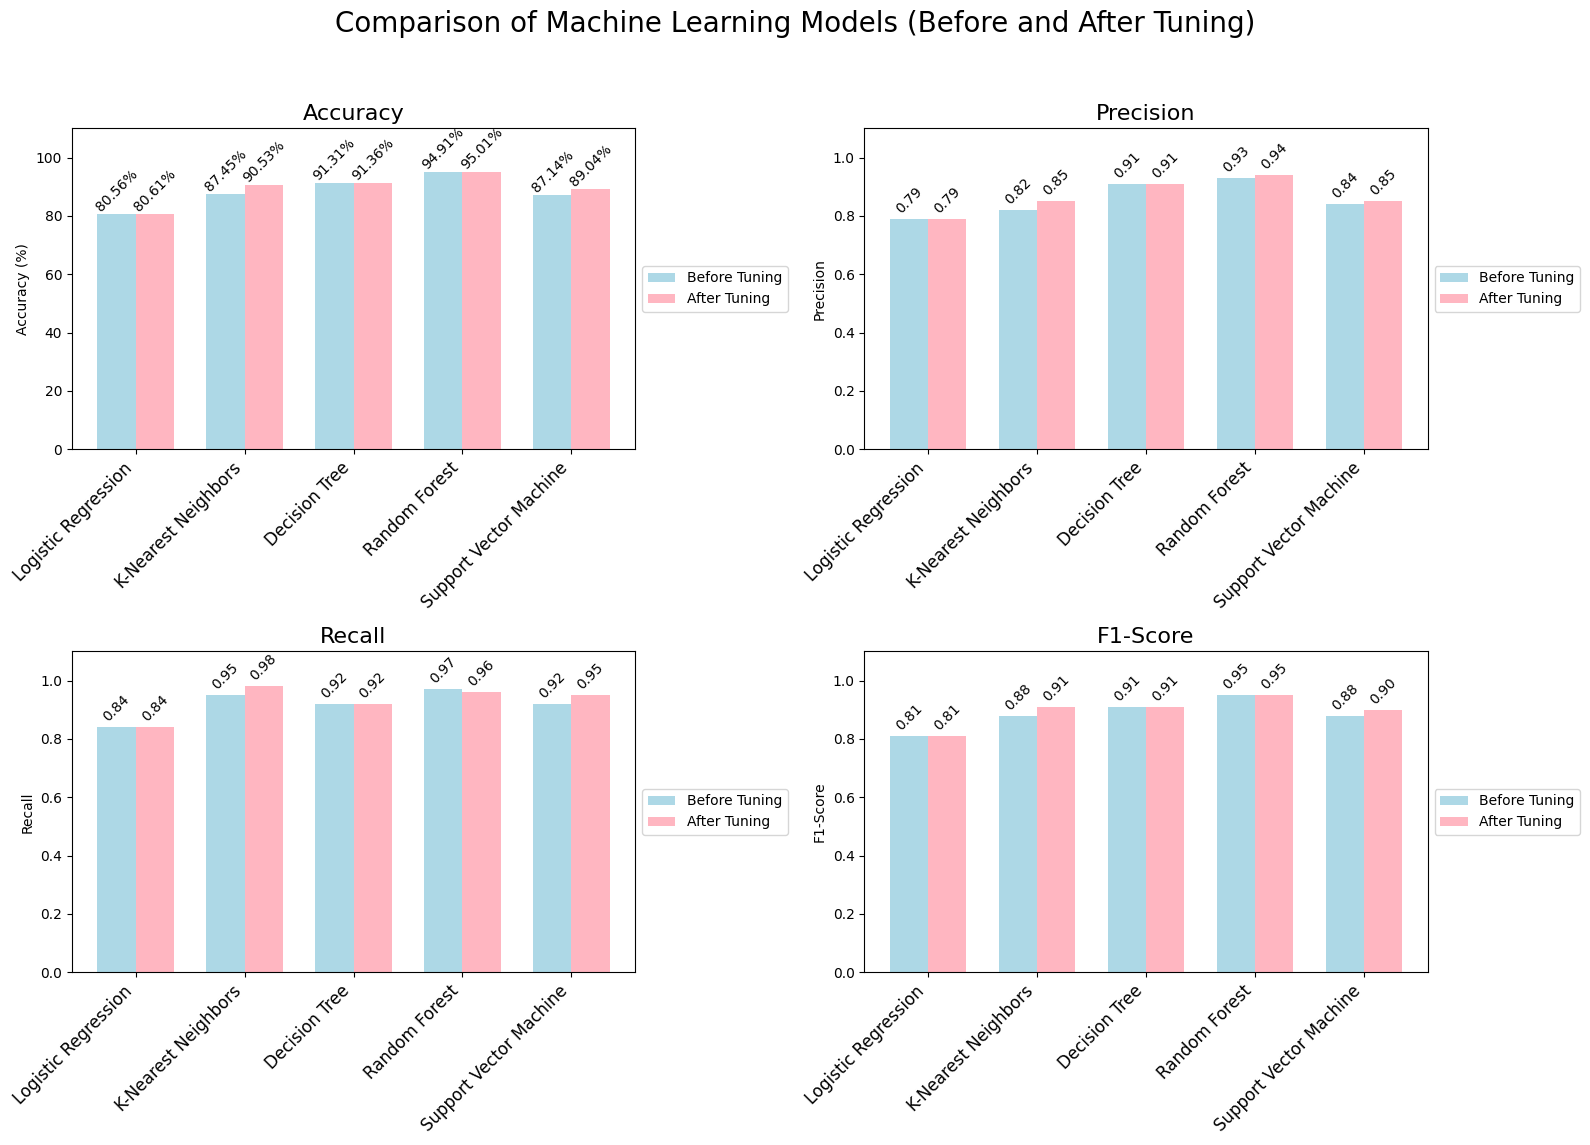

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Podaci za modele (logistic regression, knn, decision tree, random forest, svm)
models = ['Logistic Regression', 'K-Nearest Neighbors', 'Decision Tree', 'Random Forest', 'Support Vector Machine']

# Podaci pre i posle tuninga
accuracy_before_tuning = [80.56, 87.45, 91.31, 94.91, 87.14]
accuracy_after_tuning = [80.61, 90.53, 91.36, 95.01, 89.04]

precision_before_tuning = [0.79, 0.82, 0.91, 0.93, 0.84]
precision_after_tuning = [0.79, 0.85, 0.91, 0.94, 0.85]

recall_before_tuning = [0.84, 0.95, 0.92, 0.97, 0.92]
recall_after_tuning = [0.84, 0.98, 0.92, 0.96, 0.95]

f1_before_tuning = [0.81, 0.88, 0.91, 0.95, 0.88]
f1_after_tuning = [0.81, 0.91, 0.91, 0.95, 0.90]

# Boje za grafikone
colors = ['#ADD8E6', '#FFB6C1']  # Svetlo plava i svetlo roza

# Kreiranje podgrafikona (grid 2x2)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))  # Proširenje visine grafikona
fig.suptitle('Comparison of Machine Learning Models (Before and After Tuning)', fontsize=20)

# Grafikon za Accuracy
x = np.arange(len(models))  # Osa x
width = 0.35  # Širina stubaca

axes[0, 0].bar(x - width/2, accuracy_before_tuning, width, label='Before Tuning', color=colors[0])
axes[0, 0].bar(x + width/2, accuracy_after_tuning, width, label='After Tuning', color=colors[1])
axes[0, 0].set_title('Accuracy', fontsize=16)
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=45, ha='right', fontsize=12)
axes[0, 0].set_ylabel('Accuracy (%)')
axes[0, 0].set_ylim(0, 110)  # Postavljanje limita y-ose da bude više prostora iznad

# Dodavanje vrednosti iznad stubaca sa rotacijom
for i in range(len(x)):
    axes[0, 0].text(i - width/2, accuracy_before_tuning[i] + 1, f'{accuracy_before_tuning[i]:.2f}%', ha='center', rotation=45, fontsize=10)
    axes[0, 0].text(i + width/2, accuracy_after_tuning[i] + 1, f'{accuracy_after_tuning[i]:.2f}%', ha='center', rotation=45, fontsize=10)

# Grafikon za Precision
axes[0, 1].bar(x - width/2, precision_before_tuning, width, label='Before Tuning', color=colors[0])
axes[0, 1].bar(x + width/2, precision_after_tuning, width, label='After Tuning', color=colors[1])
axes[0, 1].set_title('Precision', fontsize=16)
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(models, rotation=45, ha='right', fontsize=12)
axes[0, 1].set_ylabel('Precision')
axes[0, 1].set_ylim(0, 1.1)  # Proširenje y-ose

# Dodavanje vrednosti iznad stubaca sa rotacijom
for i in range(len(x)):
    axes[0, 1].text(i - width/2, precision_before_tuning[i] + 0.02, f'{precision_before_tuning[i]:.2f}', ha='center', rotation=45, fontsize=10)
    axes[0, 1].text(i + width/2, precision_after_tuning[i] + 0.02, f'{precision_after_tuning[i]:.2f}', ha='center', rotation=45, fontsize=10)

# Grafikon za Recall
axes[1, 0].bar(x - width/2, recall_before_tuning, width, label='Before Tuning', color=colors[0])
axes[1, 0].bar(x + width/2, recall_after_tuning, width, label='After Tuning', color=colors[1])
axes[1, 0].set_title('Recall', fontsize=16)
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=45, ha='right', fontsize=12)
axes[1, 0].set_ylabel('Recall')
axes[1, 0].set_ylim(0, 1.1)

# Dodavanje vrednosti iznad stubaca sa rotacijom
for i in range(len(x)):
    axes[1, 0].text(i - width/2, recall_before_tuning[i] + 0.02, f'{recall_before_tuning[i]:.2f}', ha='center', rotation=45, fontsize=10)
    axes[1, 0].text(i + width/2, recall_after_tuning[i] + 0.02, f'{recall_after_tuning[i]:.2f}', ha='center', rotation=45, fontsize=10)

# Grafikon za F1-Score
axes[1, 1].bar(x - width/2, f1_before_tuning, width, label='Before Tuning', color=colors[0])
axes[1, 1].bar(x + width/2, f1_after_tuning, width, label='After Tuning', color=colors[1])
axes[1, 1].set_title('F1-Score', fontsize=16)
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(models, rotation=45, ha='right', fontsize=12)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_ylim(0, 1.1)

# Dodavanje vrednosti iznad stubaca sa rotacijom
for i in range(len(x)):
    axes[1, 1].text(i - width/2, f1_before_tuning[i] + 0.02, f'{f1_before_tuning[i]:.2f}', ha='center', rotation=45, fontsize=10)
    axes[1, 1].text(i + width/2, f1_after_tuning[i] + 0.02, f'{f1_after_tuning[i]:.2f}', ha='center', rotation=45, fontsize=10)

# Pomicanje legende pored grafikona
for ax in axes.flat:
    ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10)

# Prikaz grafika
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
